In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# EDA


In [3]:
df = pd.read_csv('AppleStore.csv')

df.head()


,Unnamed: 0,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,1,281656475,PAC-MAN Premium,100788224,USD,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,1
1,2,281796108,Evernote - stay organized,158578688,USD,0.00,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,1
2,3,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,USD,0.00,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,1
3,4,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128512000,USD,0.00,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,1
4,5,282935706,Bible,92774400,USD,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,1


In [4]:
df.drop(columns=["Unnamed: 0", "id"], inplace=True)

df = df[(df["user_rating"] >= 0) & (df["user_rating"] <= 5)]

df_clean = df[df["price"] >= 0]

df.drop_duplicates(subset="track_name", keep="first", inplace=True)

df_clean.reset_index(drop=True, inplace=True)

df.isnull().sum()

,0
track_name,0
size_bytes,0
currency,0
price,0
rating_count_tot,0
rating_count_ver,0
user_rating,0
user_rating_ver,0
ver,0
cont_rating,0


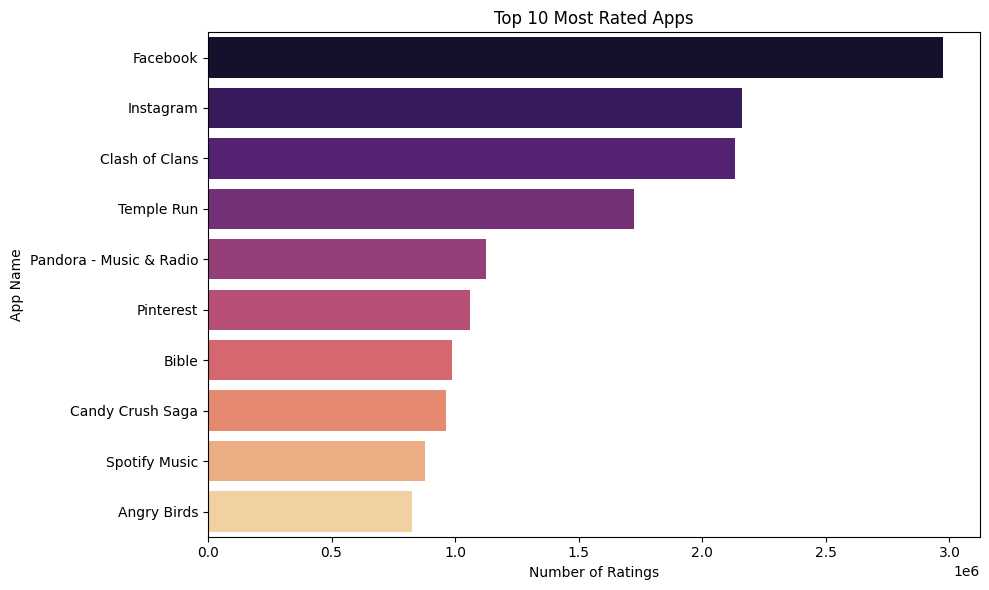

In [20]:
top_rated_apps = df.sort_values(by="rating_count_tot", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="rating_count_tot", y="track_name", data=top_rated_apps, palette="magma")
plt.title("Top 10 Most Rated Apps")
plt.xlabel("Number of Ratings")
plt.ylabel("App Name")
plt.tight_layout()
plt.show()

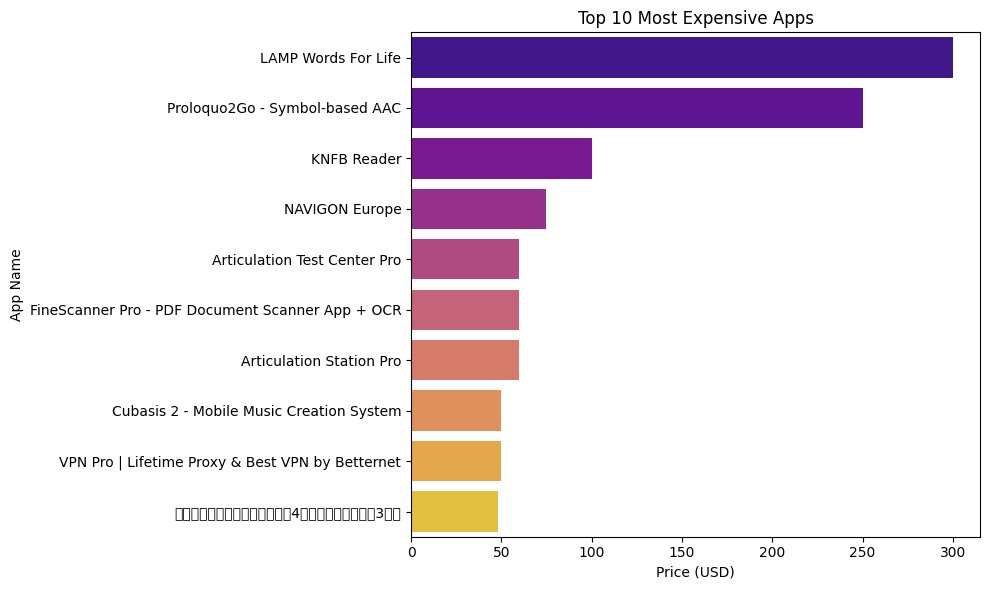

In [21]:
most_expensive_apps = df[df["price"] > 0].sort_values(by="price", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="price", y="track_name", data=most_expensive_apps, palette="plasma")
plt.title("Top 10 Most Expensive Apps")
plt.xlabel("Price (USD)")
plt.ylabel("App Name")
plt.tight_layout()
plt.show()

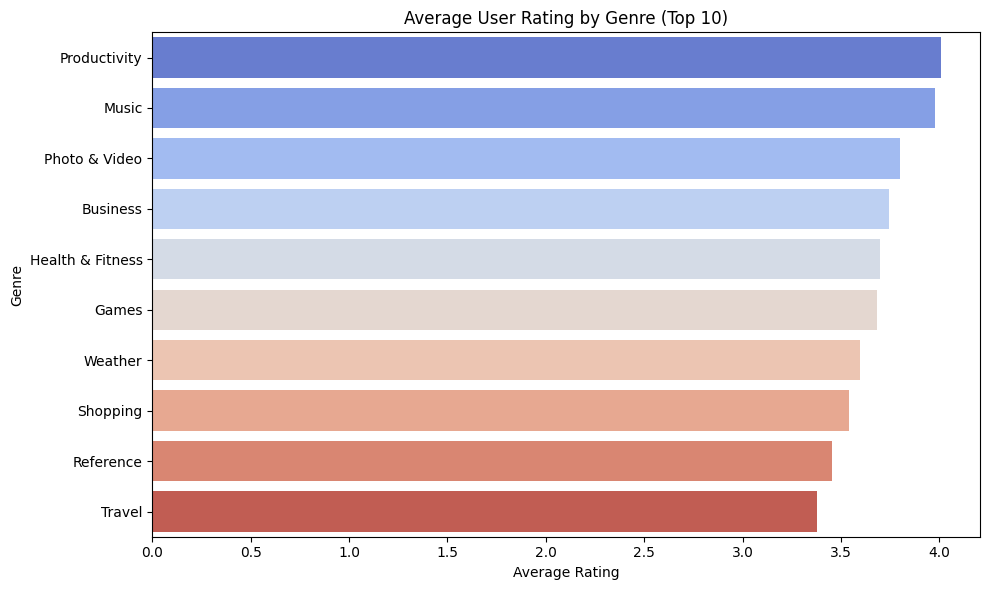

In [22]:
avg_rating_by_genre = df.groupby("prime_genre")["user_rating"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_rating_by_genre.values, y=avg_rating_by_genre.index, palette="coolwarm")
plt.title("Average User Rating by Genre (Top 10)")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

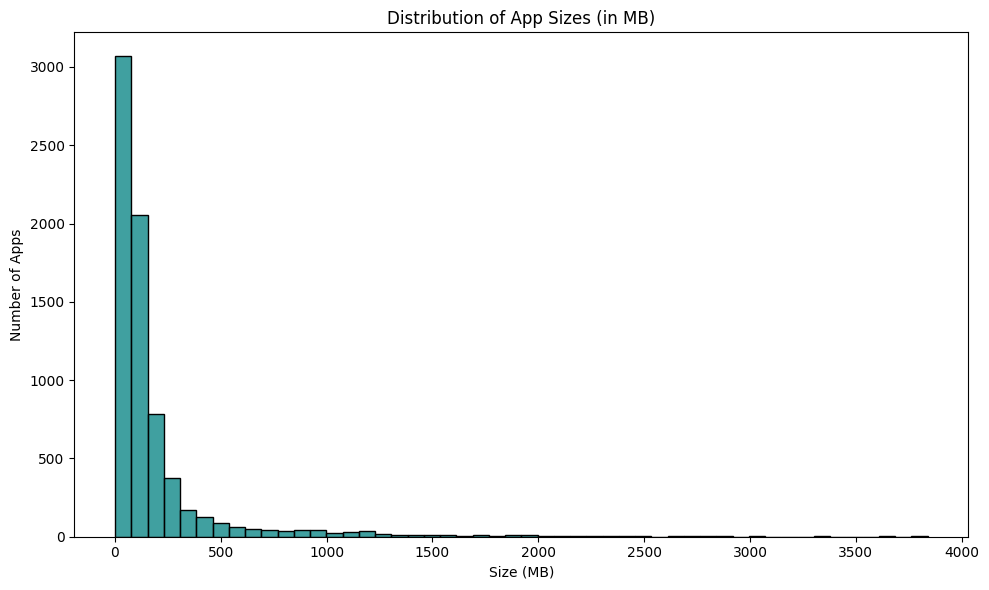

In [23]:
df["size_MB"] = df["size_bytes"] / (1024 * 1024)

plt.figure(figsize=(10, 6))
sns.histplot(df["size_MB"], bins=50, color="teal")
plt.title("Distribution of App Sizes (in MB)")
plt.xlabel("Size (MB)")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

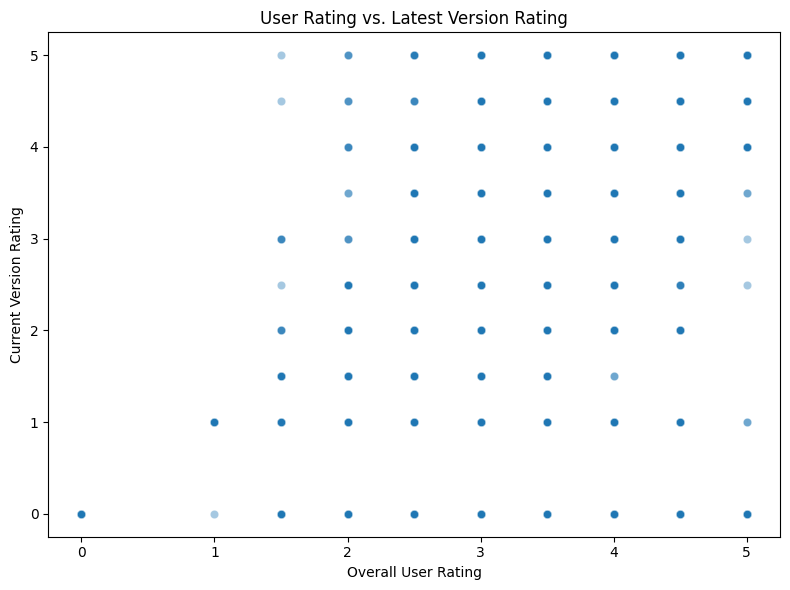

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="user_rating", y="user_rating_ver", alpha=0.4)
plt.title("User Rating vs. Latest Version Rating")
plt.xlabel("Overall User Rating")
plt.ylabel("Current Version Rating")
plt.tight_layout()
plt.show()
